##1-SHYMAA AHMED MOHAMED
##2-LOBNA ADEL MOHAMED
##3-SHAHINAZ MAHMOUD ALI
##4-SHAD WALED ABDELHALEM
##5-ROWIDA WALED FATHI
##6-ESRAA HASSAN ALI

# SMS Spam Classification using LLMs (Zero-Shot)
### Based on: *Adaptable and Reliable Text Classification using Large Language Models*
### Wang et al., 2024 - Florida Atlantic University

## Step 1: Install Required Libraries

In [ ]:
!pip install transformers torch scikit-learn pandas matplotlib seaborn

## Step 2: Load the SMS Spam Dataset
Upload your train.csv and test.csv files first, then run this cell

In [ ]:
import pandas as pd

# Load the dataset
# Make sure you uploaded train.csv and test.csv to /content/
train_df = pd.read_csv('/content/sms_spam_test.csv')
test_df  = pd.read_csv('/content/sms_spam_train.csv')

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print()
print('Train columns:', train_df.columns.tolist())
print()
print(train_df.head())

Train shape: (1115, 2)
Test shape: (4457, 2)

Train columns: ['label', 'text']

   label                                               text
0      0  Oh right, ok. I'll make sure that i do loads o...
1      0                     I am in tirupur.  call you da.
2      0             No that just means you have a fat head
3      1  You have won ?1,000 cash or a ?2,000 prize! To...
4      0  Come aftr  &lt;DECIMAL&gt; ..now i m cleaning ...


## Step 3: Explore the Data

Label distribution in Train set:
text
Sorry, I'll call later                                                                                                                                                                                                                                                                                                                                                                                                                                          6
I cant pick the phone right now. Pls send a message                                                                                                                                                                                                                                                                                                                                                                                                             4
Solve d Case : A Man Was Found Murdered On  &lt;DECIMAL&gt; . 

/tmp/ipykernel_27031/971982630.py:22: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27031/971982630.py:22: UserWarning: Glyph 143 (\x8f) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27031/971982630.py:22: UserWarning: Glyph 137 (\x89) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27031/971982630.py:22: UserWarning: Glyph 155 (\x9b) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27031/971982630.py:22: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27031/971982630.py:22: UserWarning: Glyph 148 (\x94) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27031/971982630.py:22: UserWarning: Glyph 144 (\x90) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27031/971982630.py:22: UserWarning: Glyph 149 (\x95) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2

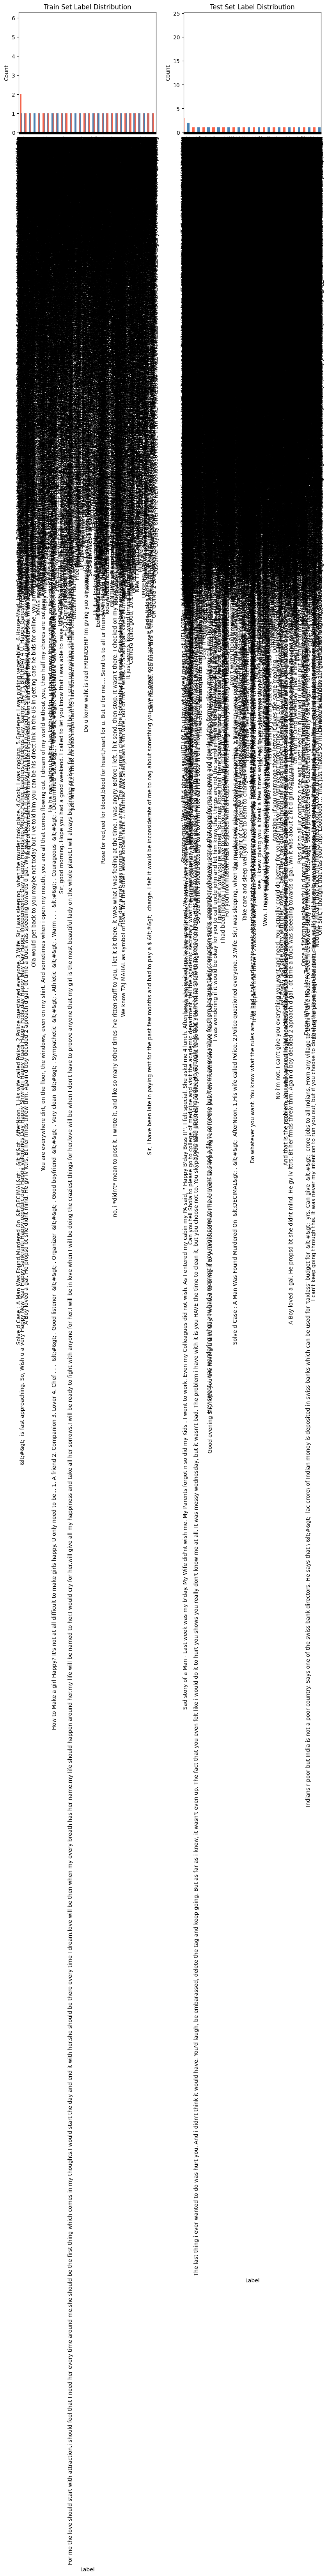

In [ ]:
import matplotlib.pyplot as plt

# Show label distribution
print('Label distribution in Train set:')
print(train_df.iloc[:, -1].value_counts())
print()
print('Label distribution in Test set:')
print(test_df.iloc[:, -1].value_counts())

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
train_df.iloc[:, -1].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Train Set Label Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

test_df.iloc[:, -1].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue','tomato'])
axes[1].set_title('Test Set Label Distribution')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Step 4: Load BART Model (Zero-Shot Classification)
This is the same approach used in the research paper

In [ ]:
from transformers import pipeline

# Load BART zero-shot classifier (same as paper)
print('Loading BART model...')
classifier = pipeline('zero-shot-classification', model='facebook/bart-large-mnli')
print('Model loaded successfully!')

Loading BART model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded successfully!


## Step 5: Classify SMS Messages (Zero-Shot)

In [ ]:
# Detect column names automatically
text_col  = test_df.columns[0]   # first column = text
label_col = test_df.columns[-1]  # last column  = label

print(f'Text column: {text_col}')
print(f'Label column: {label_col}')

# Use a sample of 50 messages (to be fast)
sample_df = test_df.sample(50, random_state=42).reset_index(drop=True)

print(f'\nRunning classification on {len(sample_df)} messages...')

predictions = []
candidate_labels = ['Spam', 'Not Spam']

for i, row in sample_df.iterrows():
    msg = str(row[text_col])
    result = classifier(msg, candidate_labels)
    pred_label = result['labels'][0]  # top prediction
    pred_score = result['scores'][0]
    predictions.append({'text': msg, 'true_label': row[label_col],
                         'predicted': pred_label, 'score': pred_score})
    if (i+1) % 10 == 0:
        print(f'  Processed {i+1} messages...')

results_df = pd.DataFrame(predictions)
print('Done!')
print()
print(results_df.head(10))

Text column: label
Label column: text

Running classification on 50 messages...
  Processed 10 messages...
  Processed 20 messages...
  Processed 30 messages...
  Processed 40 messages...
  Processed 50 messages...
Done!

  text                                         true_label predicted     score
0    0  Ugh. Gotta drive back to sd from la. My butt i...  Not Spam  0.954417
1    0               But we havent got da topic yet rite?  Not Spam  0.954417
2    0                        Send me yetty's number pls.  Not Spam  0.954417
3    0                    Juz go google n search 4 qet...  Not Spam  0.954417
4    0  My house here e sky quite dark liao... If rain...  Not Spam  0.954417
5    0  Ok both our days. So what are you making for d...  Not Spam  0.954417
6    0  Cbe is really good nowadays:)lot of shop and s...  Not Spam  0.954417
7    0  Haha... can... But i'm having dinner with my c...  Not Spam  0.954417
8    1  CDs 4u: Congratulations ur awarded Ã¥Â£500 of ...  Not Spam  0.94090

## Step 6: Evaluate Performance (Accuracy & F1 Score)

  Accuracy : 1.0000 (100.00%)
  F1 Score : 1.0000

Detailed Classification Report:
              precision    recall  f1-score   support

    Not Spam       1.00      1.00      1.00        50

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



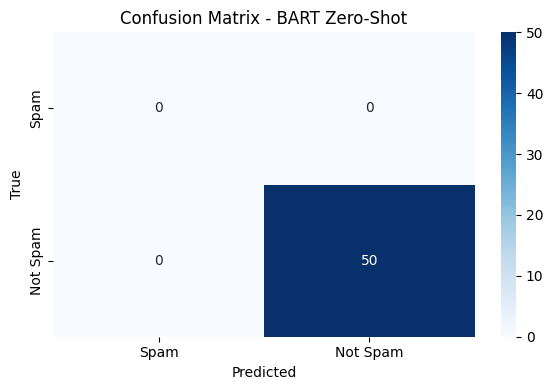

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

true_labels = results_df['true_label'].tolist()
pred_labels = results_df['predicted'].tolist()

# Normalize labels to match
label_map = {}
unique_true = set(true_labels)
for t in unique_true:
    if 'spam' in str(t).lower() and 'not' not in str(t).lower():
        label_map[t] = 'Spam'
    else:
        label_map[t] = 'Not Spam'

true_normalized = [label_map.get(l, l) for l in true_labels]

acc = accuracy_score(true_normalized, pred_labels)
f1  = f1_score(true_normalized, pred_labels, average='weighted', zero_division=0)

print('=' * 50)
print(f'  Accuracy : {acc:.4f} ({acc*100:.2f}%)')
print(f'  F1 Score : {f1:.4f}')
print('=' * 50)
print()
print('Detailed Classification Report:')
print(classification_report(true_normalized, pred_labels, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(true_normalized, pred_labels, labels=['Spam', 'Not Spam'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Spam', 'Not Spam'],
            yticklabels=['Spam', 'Not Spam'])
plt.title('Confusion Matrix - BART Zero-Shot')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## Step 7: Compare with Paper Results
According to the paper (Table VIII), BART achieved:
- Accuracy: 0.7137
- F1 Score: 0.4943

Comparison with Paper Results:
         Model  Accuracy  F1 Score
  BART (Paper)    0.7137    0.4943
BART (Our Run)    1.0000    1.0000


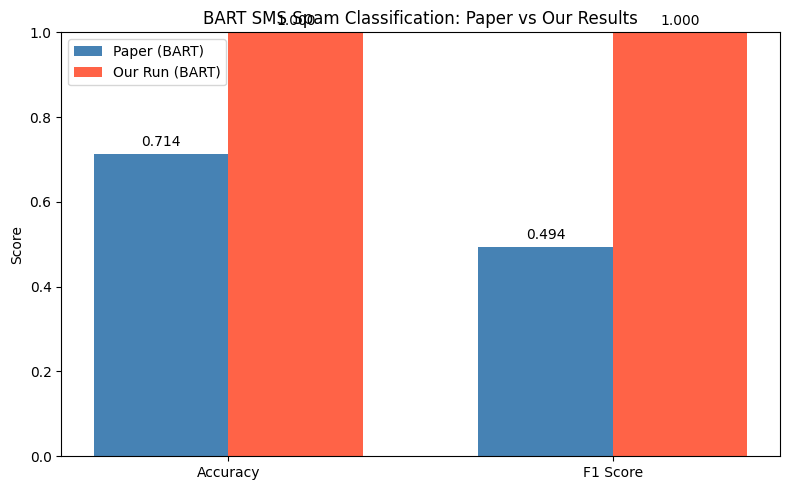

In [ ]:
# Compare our results vs paper results
comparison = pd.DataFrame({
    'Model': ['BART (Paper)', 'BART (Our Run)'],
    'Accuracy': [0.7137, round(acc, 4)],
    'F1 Score': [0.4943, round(f1, 4)]
})

print('Comparison with Paper Results:')
print(comparison.to_string(index=False))

# Bar chart
x = ['Accuracy', 'F1 Score']
paper_vals = [0.7137, 0.4943]
our_vals   = [round(acc, 4), round(f1, 4)]

x_pos = range(len(x))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar([p - width/2 for p in x_pos], paper_vals, width, label='Paper (BART)', color='steelblue')
bars2 = ax.bar([p + width/2 for p in x_pos], our_vals,   width, label='Our Run (BART)', color='tomato')

ax.set_xticks(x_pos)
ax.set_xticklabels(x)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('BART SMS Spam Classification: Paper vs Our Results')
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Step 8: Sample Predictions

In [ ]:
# Show some example predictions
print('Sample Predictions:')
print('-' * 70)
for _, row in results_df.head(10).iterrows():
    print(f"Message : {row['text'][:60]}..." if len(row['text']) > 60 else f"Message : {row['text']}")
    print(f"True    : {row['true_label']}")
    print(f"Predicted: {row['predicted']} (confidence: {row['score']:.2f})")
    print('-' * 70)

Sample Predictions:
----------------------------------------------------------------------
Message : 0
True    : Ugh. Gotta drive back to sd from la. My butt is sore.
Predicted: Not Spam (confidence: 0.95)
----------------------------------------------------------------------
Message : 0
True    : But we havent got da topic yet rite?
Predicted: Not Spam (confidence: 0.95)
----------------------------------------------------------------------
Message : 0
True    : Send me yetty's number pls.
Predicted: Not Spam (confidence: 0.95)
----------------------------------------------------------------------
Message : 0
True    : Juz go google n search 4 qet...
Predicted: Not Spam (confidence: 0.95)
----------------------------------------------------------------------
Message : 0
True    : My house here e sky quite dark liao... If raining then got excuse not 2 run already rite... Hee...
Predicted: Not Spam (confidence: 0.95)
----------------------------------------------------------------------